Model performance graphs

In [25]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import os
import tqdm


100%|██████████| 6/6 [00:00<00:00, 489.56it/s]


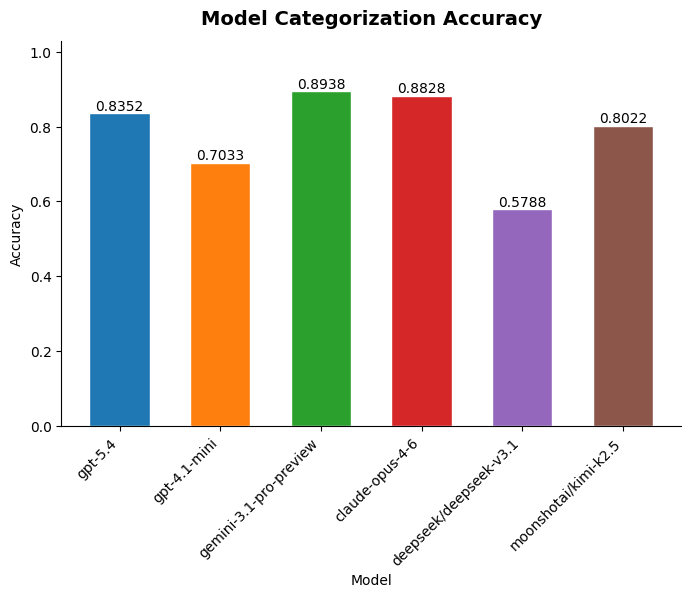

In [ ]:

DATA_DIR = "data"
# --- Data ---
models = ["gpt-5.4", "gpt-4.1-mini", "gemini-3.1-pro-preview", "claude-opus-4-6", "deepseek/deepseek-v3.1", "moonshotai/kimi-k2.5"]
model_csvs = ["gpt_5_4", "gpt_4_1_mini", "gemini_3_1_pro_preview", "claude_opus_4_6", "deepseek_v3_1", "kimi_k2_5"]

accuracies = []
df_expected = pd.read_csv(os.path.join("..", DATA_DIR, "CLEANED_cleaned_budget_data.csv"))
# expected and model prediction
for model_csv in tqdm.tqdm(model_csvs):
    df_model = pd.read_csv(os.path.join("..", DATA_DIR, "llm", model_csv+".csv"))
    result = df_model["category"] == df_expected["category"]
    accuracy = (result.sum() / result.size)
    accuracies.append(accuracy)

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, accuracies, color=cm.tab10(range(len(models))), edgecolor="white", width=0.6)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height,
            f"{height:.4f}", ha="center", va="bottom", fontsize=10)

# --- Style ---
ax.set_title("Model Categorization Accuracy", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, max(accuracies) * 1.15)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha="right")

plt.savefig("bar_chart.png", dpi=150)
plt.show()